<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
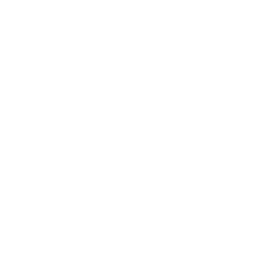
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">投薬エラー率EWMAトレンド分析</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; ヘルスケア / 患者安全 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この分析は、PROC MACONTROLによる**指数加重移動平均（EWMA）管理図**を用いて、病院集中治療室（ICU）における週次投薬エラー率を監視する。ICUは観測期間の第51週に新しい電子投薬記録（eMAR）システムを導入した。患者安全チームは、被害報告が四半期分蓄積する前に、エラーの持続的な上昇を素早く検知する早期警戒手法を必要としている。

平滑化重み **lambda = 0.3** のEWMA管理図は2段階で構築する。まず安定した移行前ベースライン（第1〜50週）から管理限界を確立し、次に全100週分の系列をその固定限界に対して監視する。管理図はベースライン期間を通じて管理内にとどまり、**稼働開始直後の最初の週**で管理外れの兆候を示す。これは、eMAR移行が通常の週次ノイズではなく、エラー率の実質的かつ持続的な変化と一致していたことを裏付けている。

## データソース

| ソース | 説明 | レコード数 |
|---------|---------|---------|
| WORK.ICU_ERRORS | 1つのICUについて、1,000件の投与あたりの週次投薬エラー率、100週連続分 | 100 |

1つのICUを週次で追跡する。各レコードには週番号、1,000件投与あたりのエラー率、投与件数、および算出されたエラー件数が保持される。文書化されたプロセス変更（eMAR稼働開始）が第51週に発生し、背後にあるエラー率の平均を1,000件あたり約1.6件上方に押し上げる。

---

In [1]:
/* --------------------------------------------------------
   週次ICU投薬エラーデータを生成する
   1つのICUについて100週連続分。
   第51週に新しいeMARシステムが稼働開始し、背後にある
   エラー率の平均を1,000件あたり約3.5件から約5.1件へ
   引き上げる。
   -------------------------------------------------------- */
データ work.icu_errors;
    呼出 streaminit(42);
    長さ unit_name $12 phase $30;
    unit_name = 'ICU';
    base_rate  = 3.5;   /* 移行前の平均率 / 1,000件 */
    unit_sigma = 0.45;  /* 週ごとの通常変動（共通原因ノイズ） */
    繰返 week_num = 1 から 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        もし administrations < 300 なら administrations = 300;
        /* eMAR移行により第50週以降は平均が上昇する */
        もし week_num > 50 なら 繰返;
            phase = 'eMAR導入後';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        終了;
        他 繰返;
            phase = 'ベースライン';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        終了;
        もし error_rate_per_1k < 0 なら error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        出力;
    終了;
    削除 base_rate unit_sigma;
    書式 week_start_date date9.;
実行;



NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                               ICUエラー率: ベースライン vs eMAR導入後                                               

                                                  The MEANS Procedure

                         Analysis Variable : error_rate_per_1k 1,000件あたりのエラー率

        フェーズ                        N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------
        eMAR導入後                        50           5.11           0.44           3.69           5.96
        ベースライン                         50           3.50           0.48           2.55           4.71
        ---------------------------------------------------------------------------------------------

                                    Analysis Variable : error_count エラー件数

        フェーズ                        N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


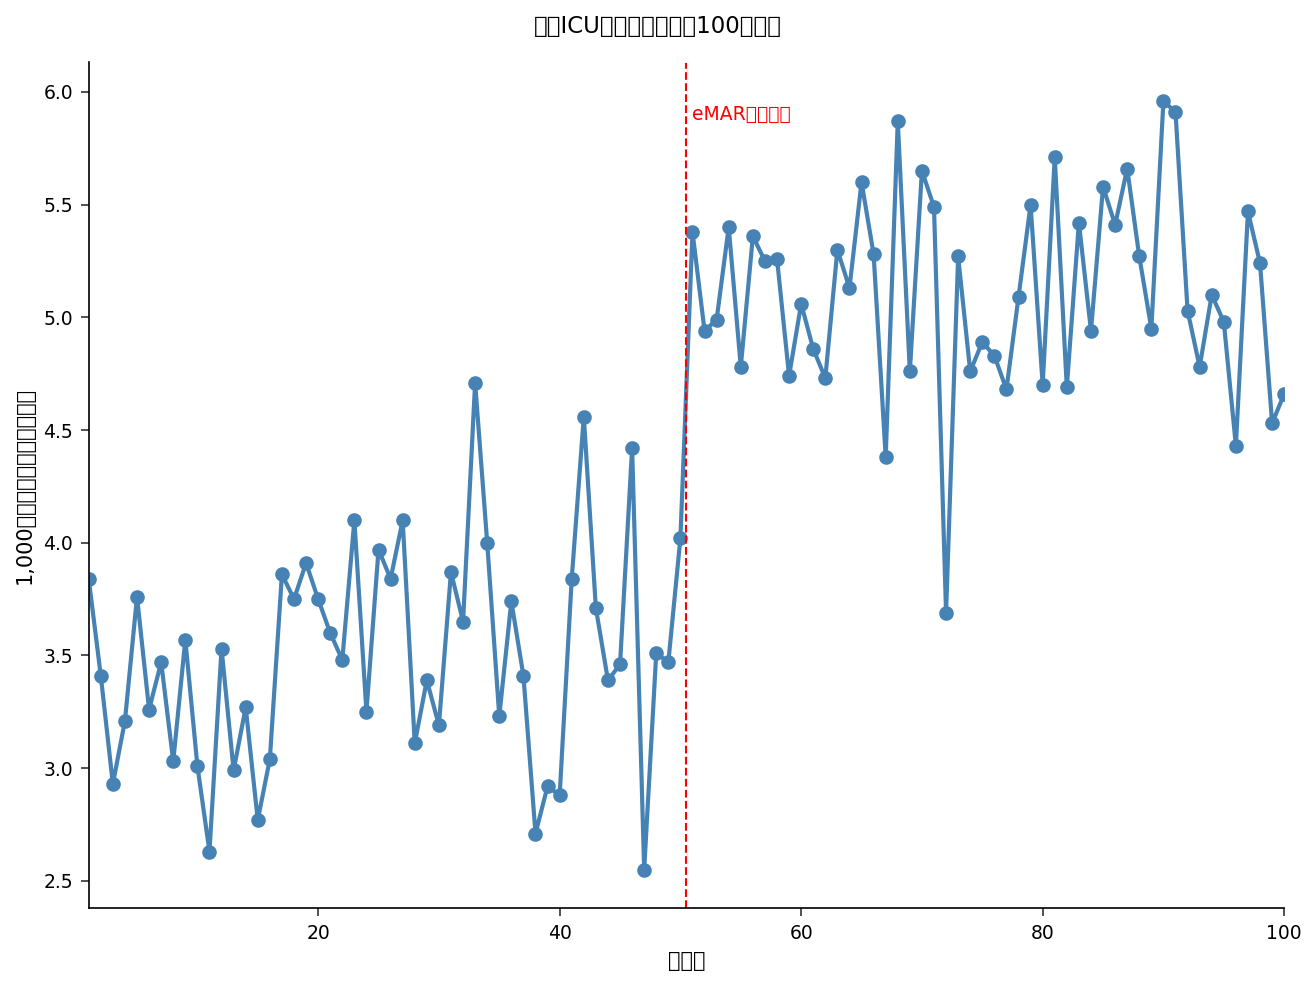

In [2]:
/* --------------------------------------------------------
   eMAR稼働開始の前後でエラー率を比較し、
   週次トレンドをプロットする。
   -------------------------------------------------------- */
処理 平均 データ=work.icu_errors n mean std MIN MAX maxdec=2;
    分類 phase;
    変数 error_rate_per_1k error_count administrations;
    見出 phase             = 'フェーズ'
          error_rate_per_1k = '1,000件あたりのエラー率'
          error_count       = 'エラー件数'
          administrations   = '投与件数';
    表題 'ICUエラー率: ベースライン vs eMAR導入後';
実行;

処理 SGPLOT データ=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   見出='eMAR稼働開始';
    XAXIS 見出='週番号';
    YAXIS 見出='1,000件投与あたりのエラー率';
    表題 '週次ICU投薬エラー率（100週間）';
実行;


---

In [3]:
/* --------------------------------------------------------
   フェーズI: 安定した移行前ベースライン（第1〜50週）から
   EWMA管理限界を確立する。この固定限界が、
   全監視期間を測る基準となる。
   -------------------------------------------------------- */
処理 平均 データ=work.icu_errors(条件=(week_num <= 50)) NOPRINT;
    変数 error_rate_per_1k;
    出力 out=work.baseline_stats mean=base_mean std=base_std;
実行;

データ work.icu_limits;
    設定 work.baseline_stats;
    長さ _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* ベースラインの中心線 */
    _STDDEV_ = base_std;    /* ベースラインの共通原因シグマ */
    _LIMITN_ = 1;
    保持 _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
実行;

処理 印刷 データ=work.icu_limits noobs;
    表題 'フェーズI 管理限界の入力値（ベースライン第1〜50週）';
実行;


                                              フェーズI 管理限界の入力値（ベースライン第1〜50週）                                              

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                              フェーズI 管理限界の入力値（ベースライン第1〜50週）                                              


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/399eb67b-e608-45e0-9287-5d53c5a01d0f/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


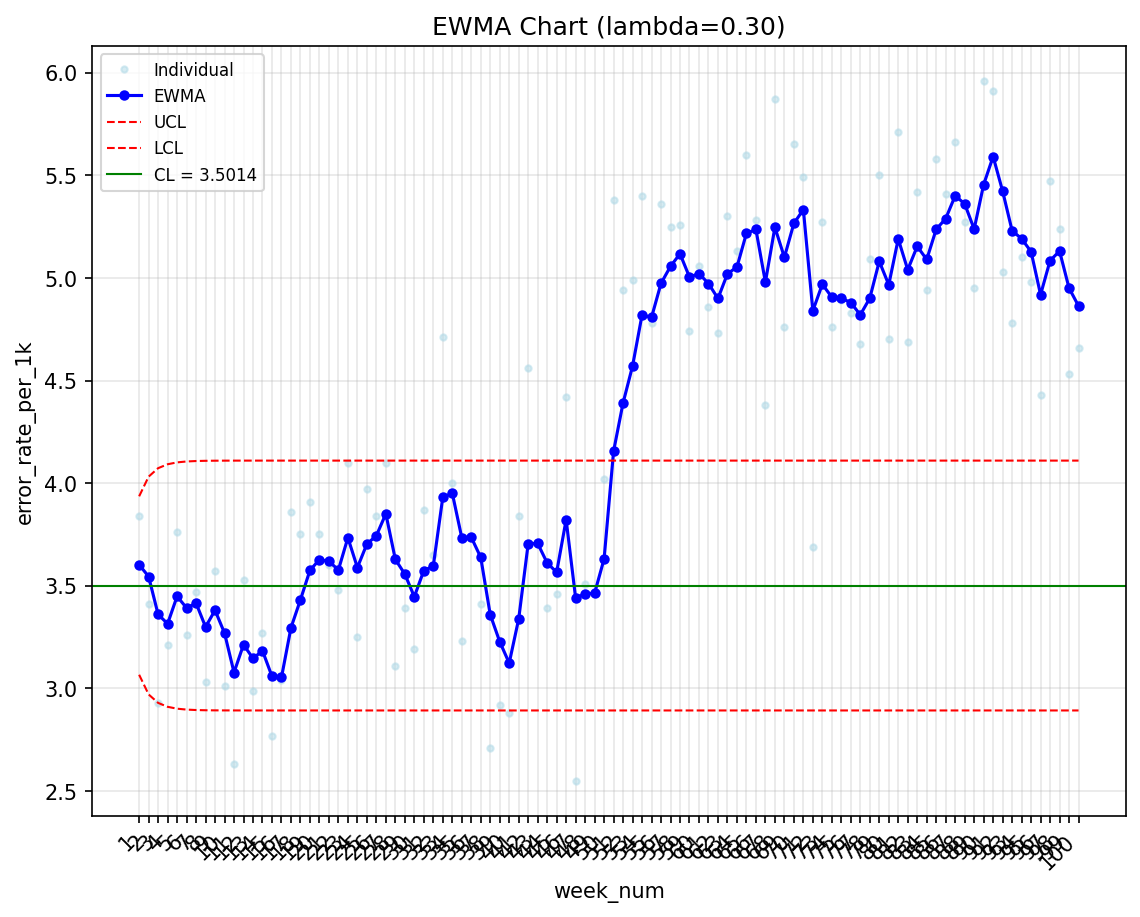

In [4]:
/* --------------------------------------------------------
   フェーズII: 全100週の系列を固定ベースライン限界に対して
   監視する。lambda=0.3は患者安全モニタリングに適した
   即応性の高い検知を与える。
   -------------------------------------------------------- */
処理 macontrol データ=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        重み    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    見出 error_rate_per_1k =
          '1,000件投与あたりの投薬エラー数';
    表題 'EWMA管理図: ICU投薬エラー率（lambda=0.3）';
実行;


---

In [5]:
/* --------------------------------------------------------
   EWMAがベースライン限界を逸脱したすべての週を特定し、
   管理図が最初に兆候を示した時点を報告する。
   -------------------------------------------------------- */
データ work.signals;
    設定 work.icu_table;
    条件 _EXLIM_ ne ' ' かつ _EXLIM_ ne '0';
実行;

処理 SQL;
    選択 count(*)        AS n_signals          見出='シグナル週数',
           MIN(week_num)    AS first_signal_week  見出='初回シグナル週',
           MAX(_EWMA_)      AS peak_ewma 書式=6.3 見出='EWMAピーク値'
    FROM work.signals;
QUIT;

処理 印刷 データ=work.signals(obs=8);
    変数 week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    見出 week_num           = '週番号'
          error_rate_per_1k  = '1,000件あたりのエラー率';
    表題 '管理限界外れの初期EWMAシグナル';
実行;


                                              フェーズI 管理限界の入力値（ベースライン第1〜50週）                                              

            シグナル週数                初回シグナル週          EWMAピーク値
------------------  ---------------------  ----------------
                50                   51.0             5.591
                                                   管理限界外れの初期EWMAシグナル                                                    

  Obs        週番号    _EWMA_   _UCLE_  _EXLIM_
    1         51  4.155551  4.10998        1
    2         52  4.390886  4.10998        1
    3         53   4.57062  4.10998        1
    4         54  4.819434  4.10998        1
    5         55  4.807604  4.10998        1
    6         56  4.973323  4.10998        1
    7         57  5.056326  4.10998        1
    8         58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### 結果の解釈

2段階のEWMA分析は、通常の週次変動とeMAR稼働開始時の実質的なプロセス変化を明確に切り分ける。

**ベースライン（第1〜50週）。** PROC MEANSは、ベースライン期間の平均エラー率を**1,000件あたり3.50件**（標準偏差0.48）と報告しており、移行後の平均**5.11**（標準偏差0.44）と対比すると、**1,000件あたり約1.6件**の持続的な上方シフトが見られる。投与件数は両フェーズ間で同程度（週あたり795件 vs 790件）であり、この変化はワークロードの増減ではなくエラー*率*そのものを反映している。

**管理限界。** 限界はベースラインのみから固定される: 中心線**3.5014**、ベースラインシグマ**0.4829**。平滑化重みlambda = 0.3と3シグマ限界の下で、EWMA上側限界は漸近値の約**4.11**に落ち着く。第1〜50週を通じてEWMA統計量はこの限界内にとどまり —— ベースラインは**誤検知ゼロ**を達成し、管理図が過敏でないことを裏付けている。

**検知。** 管理図は稼働開始直後の**最初の週（第51週）**で管理外れを検知し、EWMAは**4.156**に達して限界4.11をわずかに上回る。それ以降、統計量は着実に上昇を続け、移行後期間の全体を通じて上側限界を上回り続ける: **移行後の全50週（第51〜100週）がシグナルを発し**、EWMAは第91週前後で**5.591**とピークに達する。lambda = 0.3の即応性により、数週間分の蓄積を待たずに悪化が直ちに検知される。

**対応。** eMAR導入の週から始まる持続的なEWMA逸脱は、それが偶然ではなく新システムがエラー増加を引き起こしたことを示す強力な証拠である。患者安全委員会は第51週を変化点として扱い、その週に導入されたeMARの与薬オーダーおよびオーバーライドのワークフローを監査し、EWMAが4.11を下回るまで元のベースライン限界に対する管理図の運用を継続すべきである。エクスポートされた `icu_ewma_signals.csv`（シグナル50週分）と `icu_ewma_table.csv` は、ジョイントコミッションの継続的レディネスレビューに向けた文書化されたSPCエビデンスの証跡となる。

---

In [6]:
/* --------------------------------------------------------
   ジョイントコミッション継続的レディネス文書化のため、
   EWMAテーブルとシグナル一覧をエクスポートする。
   -------------------------------------------------------- */
処理 EXPORT データ=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
実行;



NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>